<a href="https://colab.research.google.com/github/AhmadRizkiadi/pengolahan-citra/blob/main/js4_segmentasi_gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ahmad Rizkiadi Budi Wirawan

---



# Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

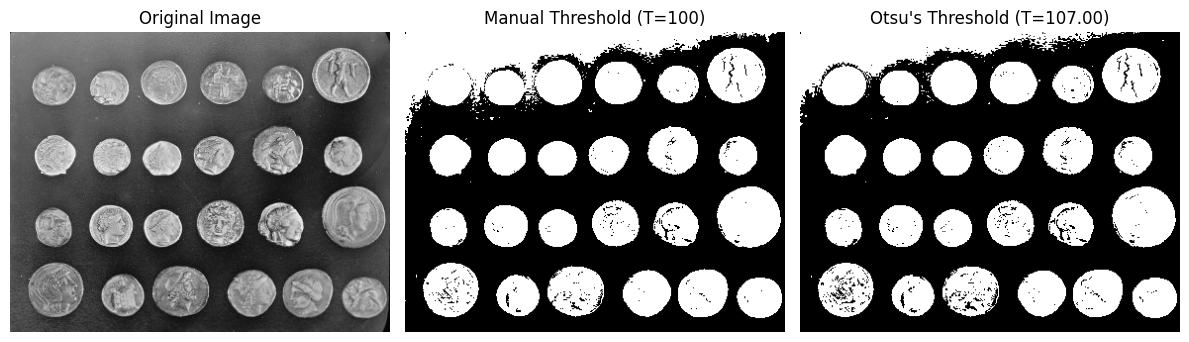

Nilai threshold Otsu yang ditemukan: 107


In [1]:
import matplotlib.pyplot as plt
from skimage import data, filters, img_as_ubyte
from skimage.color import rgb2gray

# 1.Memuat citra (contoh: coins)
image_coins = data.coins() #Citra sudah grayscale

# 2. Thresholding Global (manual)
# Tentukan nilai ambang manual, misal 100
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap=plt.cm.gray)
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap=plt.cm.gray)
ax[2].set_title(f'Otsu\'s Threshold (T={thresh_otsu:.2f})')
ax[2].axis('off')

plt.tight_layout()
plt.show()

# Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang ditemukan: {thresh_otsu}")


Amati perbedaan hasil segmentasi antara thresholding manual dan Otsu. Apakah metode Otsu  berhasil memisahkan objek (koin) dari latar belakang dengan baik pada citra ini?

---
Ya, semua objek (koin) terlihat semua, tidak kurang dan tidak lebih


# Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

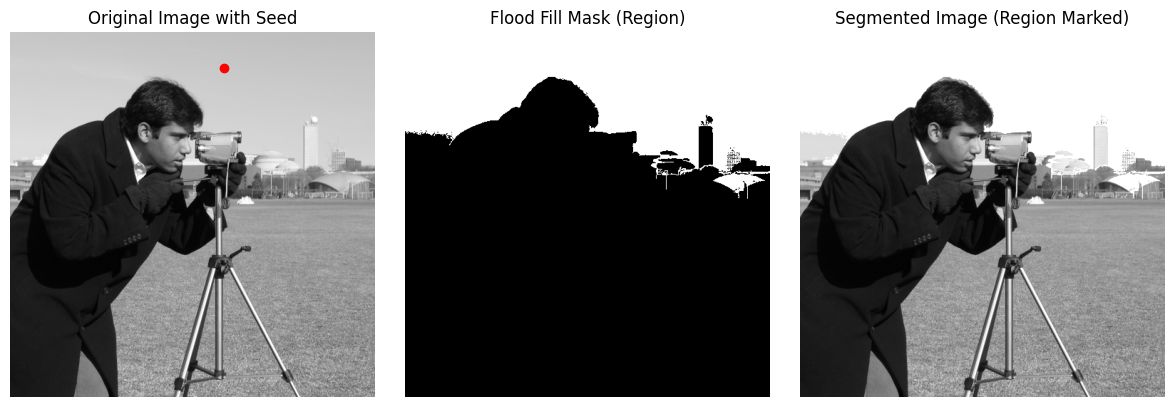

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misal, kita pilih titik di area langit (misal, koordinat y=50, x=150)
seed_point = (50, 300)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=20)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255 # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap=plt.cm.gray)
ax[0].plot(seed_point[1], seed_point[0], 'ro') # Tandai seed point
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap=plt.cm.gray)
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap=plt.cm.gray)
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()


Pengaruh parameter  tolerance terhadap ukuran region yang 'tumbuh' :
1.  Tolerance menentukan seberapa jauh perbedaan nilai intensitas piksel yang masih dianggap "sejenis" dengan piksel seed.

2.   Semakin besar nilai tolerance, semakin luas region yang akan tumbuh, karena piksel dengan nilai intensitas yang lebih jauh dari nilai seed tetap bisa masuk ke region.

3.   Sebaliknya, kalau tolerance kecil, hanya piksel dengan intensitas sangat mirip saja yang masuk ke dalam region, sehingga hasil region-nya jadi lebih kecil dan lokal.



# Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

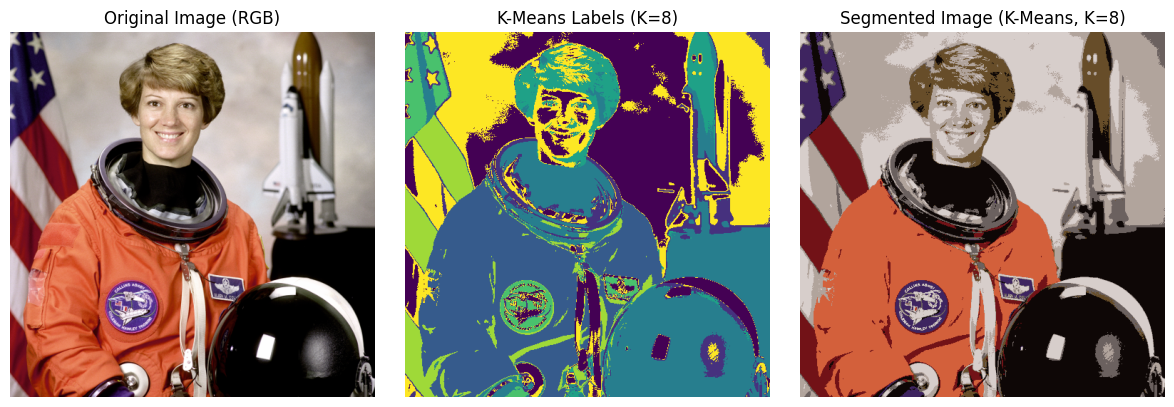

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, io
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()
# Konversi ke float untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Reshape citra menjadi array piksel [jumlah_piksel, jumlah_fitur]
# Fitur bisa RGB atau Lab. Ruang warna Lab seringkali lebih baik untuk persepsi warna.
# Konversi ke Lab
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
# Tentukan jumlah klaster (segmen) yang diinginkan, misal K=7
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10) # n_init='auto' jika versi sklearn baru
# Hiding FutureWarnings related to default value of n_init
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Reshape label kembali ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Buat citra tersegmentasi (warnai setiap segmen dengan warna rata-rata klaster)
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_
for k in range(n_clusters):
    # Dapatkan piksel yang termasuk klaster k
    cluster_pixels = (pixel_labels == k)
    # Isi piksel tersebut di citra baru dengan warna pusat klaster k
    # Perlu reshape kembali cluster_pixels ke bentuk citra
    mask_k = cluster_pixels.reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

# Menampilkan label klaster
ax[1].imshow(segmented_labels, cmap='viridis') # cmap bisa diganti
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

# Menampilkan citra hasil segmentasi K-Means
ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


**Apakah jumlah klaster (K) mempengaruhi hasil segmentasi secara signifikan?**

Iya mempegaruhi

K kecil  -> citra dibagi jadi sedikit region besar. Detail halus seperti wajah, rambut, background bisa tercampur di satu region.

K besar -> citra terbagi jadi lebih banyak region kecil, detail warna lebih terjaga, tapi bisa berlebihan kalau K terlalu besar (oversegmentasi)

jadi, Semakin besar K → segmentasi makin detail, tapi kalau terlalu besar bisa malah noisy dan susah interpretasi.

---
**Apakah penggunaan ruang warna Lab membantu?**

Iya mempengaruhi

Di ruang Lab, jarak antar warna lebih linear sesuai persepsi terang-gelap (L) dan warna (a,b), jadi hasil klasternya lebih konsisten secara visual.


# Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

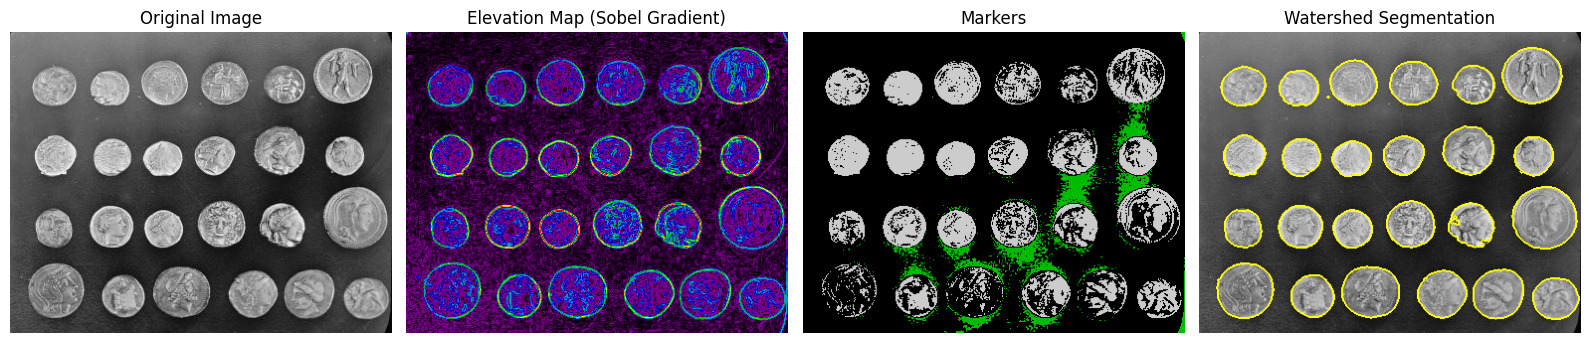

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
# Kita bisa menggunakan thresholding untuk mendapatkan marker kasar
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1  # Marker untuk latar belakang
markers[image_coins > 150] = 2 # Marker untuk objek (koin)

# Atau gunakan marker dari local maxima (lebih canggih)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Watershed Segmentation')
ax[3].axis('off')

plt.tight_layout()
plt.show()


Amati bagaimana algoritma Watershed menggunakan gradien dan marker untuk memisahkan  objek. Bagaimana pemilihan marker mempengaruhi hasil akhir? Apa yang terjadi jika marker  tidak tepat?




*   Marker yang Tepat (Akurat): Marker yang ditempatkan pada objek yang berbeda (misalnya objek koin dalam citra Anda) memungkinkan algoritma untuk memisahkan objek dengan lebih jelas. Marker yang diletakkan di area puncak dari setiap objek (seperti bagian tengah atau area yang jelas) akan memberikan hasil yang lebih baik dan lebih presisi.
*   Marker yang Tidak Tepat (Salah): Jika marker tidak ditempatkan dengan benar (misalnya, di luar objek atau terlalu dekat satu sama lain), maka algoritma akan kesulitan untuk memisahkan objek dengan benar.


# Praktikum 5. Perbandingan Visual Hasil Segmentasi

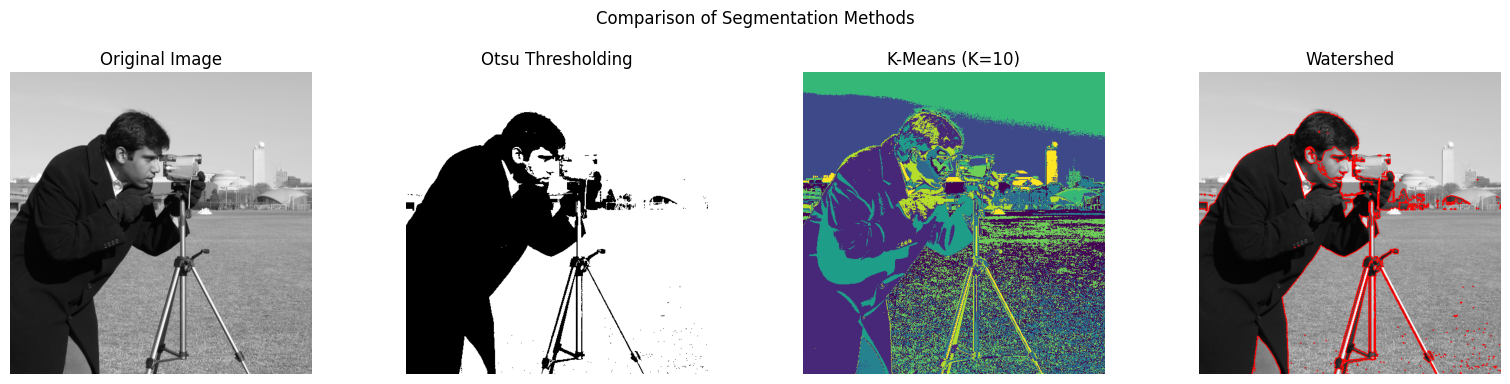

In [8]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi
# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
# Reshape untuk K-Means (1 fitur: intensitas)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)
segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

# Gunakan mark_boundaries untuk Watershed agar lebih jelas
segmented_watershed_colored = segmentation.mark_boundaries(
    image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


# Penugasan



**Eksperimen Thresholding**

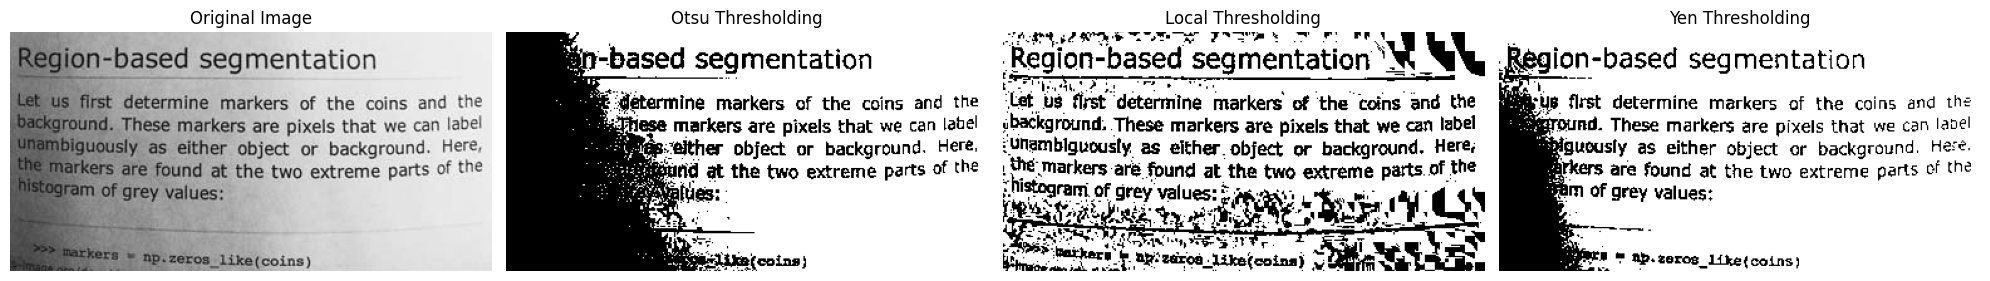

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, measure, io
from skimage.filters import threshold_otsu, threshold_local, threshold_yen
from sklearn.cluster import KMeans
from skimage import morphology

# 1. Memuat citra
image = data.page()

# 2. Metode Thresholding Otsu
threshold_otsu_value = threshold_otsu(image)
binary_otsu = image > threshold_otsu_value

# 3. Metode Thresholding Lokal
threshold_local_value = threshold_local(image, block_size=35)
binary_local = image > threshold_local_value

# 4. Metode Thresholding Yen
threshold_yen_value = threshold_yen(image)
binary_yen = image > threshold_yen_value

# Visualisasi Hasil Thresholding
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title("Otsu Thresholding")
ax[1].axis('off')

ax[2].imshow(binary_local, cmap=plt.cm.gray)
ax[2].set_title("Local Thresholding")
ax[2].axis('off')

ax[3].imshow(binary_yen, cmap=plt.cm.gray)
ax[3].set_title("Yen Thresholding")
ax[3].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, filters, segmentation, measure
from skimage.filters import threshold_otsu
from sklearn.cluster import KMeans
from scipy import ndimage as ndi

# 1. Memuat citra sederhana dari internet (misalnya citra buah-buahan)
image = io.imread("https://upload.wikimedia.org/wikipedia/commons/4/43/Apple_fruit.jpg")
image_gray = np.mean(image, axis=2)  # Mengubah citra menjadi grayscale

# 2. Metode Otsu Thresholding
threshold_otsu_value = threshold_otsu(image_gray)
binary_otsu = image_gray > threshold_otsu_value

# 3. Metode K-Means
# Kita ubah citra menjadi 2D untuk clustering K-Means
image_reshaped = image_gray.reshape((-1, 1))
kmeans = KMeans(n_clusters=2, random_state=42).fit(image_reshaped)
labels_kmeans = kmeans.labels_.reshape(image_gray.shape)
binary_kmeans = labels_kmeans == 1  # Menggunakan cluster yang lebih terang

# 4. Metode Watershed
# Menghitung gradien dan menentukan marker
elevation_map = filters.sobel(image_gray)
markers = np.zeros_like(image_gray)
markers[image_gray < 100] = 1  # Latar belakang
markers[image_gray > 150] = 2  # Objek
segmentation_watershed = segmentation.watershed(elevation_map, markers)
segmented_colored = segmentation.mark_boundaries(image_gray, segmentation_watershed)

# Visualisasi Hasil Segmentasi
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
ax = axes.ravel()

ax[0].imshow(image_gray, cmap=plt.cm.gray)
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title("Otsu Thresholding")
ax[1].axis('off')

ax[2].imshow(binary_kmeans, cmap=plt.cm.gray)
ax[2].set_title("K-Means Segmentation")
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title("Watershed Segmentation")
ax[3].axis('off')

plt.tight_layout()
plt.show()
